# **LOSS-WEIGHTED TRAINING WARNING**

**THIS NOTEBOOK USES CLASSIFICATION RESULTS TRAINED WITH CLASS-WEIGHTED LOSS INSTEAD OF WEIGHTED WINDOW SAMPLING. ITS MODEL COMPARISONS SHOULD NOT BE INTERPRETED AS RESULTS FROM THE CORRECTED SAMPLING PROCEDURE.**


# Native presynaptic trajectory diagnostics

Reproduce the checks behind the unusually similar Mean, Pointwise-MLP, and Graph Transformer trajectories. This notebook reads saved run artifacts and the CAVE/native skeleton databases; it does not train models. The mixed-cell experiment is included as a separate condition. Embedding measurements use fixed random samples of the same cells in CAVE and native b32.

The recorded validation trajectory and final reported test metric use the same test-cell split for checkpoint selection. Interpret best-epoch scores with that limitation.

Native window sizes are exact: **b32 = 9**, **b16 = 17**, and **b8 = 33** skeleton nodes per window. The Graph Transformer adds one CLS token, so its attention sequence lengths are 10, 18, and 34 respectively.

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import hashlib
import json
import random
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "results" / "presynaptic").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CAVE_RESULTS = ROOT / "results/presynaptic/cave_skeletons"
NATIVE_RESULTS = ROOT / "results/presynaptic/new_skeletons_native/local_center"
MIXED_RESULTS = ROOT / "results/presynaptic/new_skeletons_native/mixed_cell_b32"
CAVE_DB = Path("/orcd/scratch/orcd/013/jcbliao/presynaptic_axons/k10")
NATIVE_DB = Path("/orcd/scratch/orcd/013/jcbliao/presynaptic_axons/resampled_teasar_2209/training_local_center/scale32/k9")

MODEL_ORDER = ("Mean", "Pointwise-MLP", "GT")
COLORS = {"Mean": "#4C78A8", "Pointwise-MLP": "#F58518", "GT": "#54A24B"}

def model_name(run):
    if "_pointwise_mlp_" in run: return "Pointwise-MLP"
    if "_mean_" in run: return "Mean"
    if "_gt_" in run: return "GT"
    raise ValueError(run)

def artifact_paths(root):
    paths = list(root.glob("*/epoch_metrics.csv"))
    return {model_name(p.parent.name): p for p in paths}

RUN_DIRS = {
    "CAVE k10": CAVE_RESULTS,
    "native b32": NATIVE_RESULTS / "scale32/k9",
    "native b16": NATIVE_RESULTS / "scale16/k17",
    "mixed b32": MIXED_RESULTS / "scale32/k9",
}
CURVE_FILES = {name: artifact_paths(path) for name, path in RUN_DIRS.items()}
CURVES = {name: {model: pd.read_csv(path) for model, path in files.items()}
          for name, files in CURVE_FILES.items()}
{group: {model: len(frame) for model, frame in models.items()}
 for group, models in CURVES.items()}

{'CAVE k10': {'GT': 100, 'Mean': 100},
 'native b32': {'GT': 30, 'Mean': 30, 'Pointwise-MLP': 30},
 'native b16': {'GT': 30, 'Pointwise-MLP': 30, 'Mean': 30},
 'mixed b32': {'Mean': 30, 'GT': 30, 'Pointwise-MLP': 30}}

## Result provenance and model weights

The raw CSVs, run configurations, and checkpoints establish whether the curves were reused or the model architecture changed. The comparison below checks the two GT configurations and a shared classifier tensor in Mean versus Pointwise-MLP.

In [2]:
def result_json(root, model):
    return next(p for p in root.glob("*.json") if model_name(p.stem) == model)

def best_checkpoint(root, model):
    return next(p for p in root.glob("*/checkpoint_best.pt")
                if model_name(p.parent.name) == model)

artifact_rows = []
for group, root in RUN_DIRS.items():
    for model, csv_path in CURVE_FILES[group].items():
        args = json.loads(result_json(root, model).read_text())["args"]
        artifact_rows.append({
            "condition": group, "model": model, "epochs": len(CURVES[group][model]),
            "CSV SHA256 (first 12)": hashlib.sha256(csv_path.read_bytes()).hexdigest()[:12],
            "architecture": args["architecture"], "seed": args["seed"],
            "K": args["num_embeddings"], "mixed group": args.get("mixed_cell_batch_size", 0),
        })
artifact_table = pd.DataFrame(artifact_rows)
display(artifact_table.sort_values(["condition", "model"]))

cave_gt = torch.load(best_checkpoint(CAVE_RESULTS, "GT"), map_location="cpu", weights_only=False)
native_gt = torch.load(best_checkpoint(RUN_DIRS["native b32"], "GT"), map_location="cpu", weights_only=False)
mean_ckpt = torch.load(best_checkpoint(RUN_DIRS["native b32"], "Mean"), map_location="cpu", weights_only=False)
mlp_ckpt = torch.load(best_checkpoint(RUN_DIRS["native b32"], "Pointwise-MLP"), map_location="cpu", weights_only=False)
key = "cls_head.trunk.dense_layers_1.0.weight"
print("CAVE/native GT configs equal:", cave_gt["config"] == native_gt["config"])
print("CAVE/native GT parameters:", *(sum(t.numel() for t in ck["model_state"].values()) for ck in (cave_gt, native_gt)))
print("Native Mean/MLP shared-head tensor max difference:",
      float((mean_ckpt["model_state"][key] - mlp_ckpt["model_state"][key]).abs().max()))
print("Pointwise-MLP encoder tensors:",
      [k for k in mlp_ckpt["model_state"] if k.startswith("pointwise_mlp.")])

,condition,model,epochs,CSV SHA256 (first 12),architecture,seed,K,mixed group
0,CAVE k10,GT,100,329ddc430236,graph_transformer,0,10,0
1,CAVE k10,Mean,100,16cf71c7475d,mean,0,10,0
9,mixed b32,GT,30,9908d7ca6d69,graph_transformer,0,9,16
8,mixed b32,Mean,30,c1bc5633a621,mean,0,9,16
10,mixed b32,Pointwise-MLP,30,aa68839e5e16,pointwise_mlp,0,9,16
5,native b16,GT,30,a61162d73870,graph_transformer,0,17,0
7,native b16,Mean,30,7a9f84edad1b,mean,0,17,0
6,native b16,Pointwise-MLP,30,ffd64c7a20e9,pointwise_mlp,0,17,0
2,native b32,GT,30,80f829ebed52,graph_transformer,0,9,0
3,native b32,Mean,30,acb94d4c46df,mean,0,9,0


CAVE/native GT configs equal: True
CAVE/native GT parameters: 1797263 1797263
Native Mean/MLP shared-head tensor max difference: 0.2799069881439209
Pointwise-MLP encoder tensors: ['pointwise_mlp.phi.0.weight', 'pointwise_mlp.phi.0.bias', 'pointwise_mlp.phi.2.weight', 'pointwise_mlp.phi.2.bias']


The ordinary GT has the same depth, heads, feature paths, and parameter count in both experiments. Its implementation now broadcasts adjacency and learned attention weights across heads instead of making explicit per-head copies; the calculation is the same. The new `has_segclr` argument is ignored by the ordinary GT.

## Runtime provenance

The earlier CAVE GT completed 100 epochs in Slurm job `22246050_0`; native b32 GT completed 30 in `22822552_1`. Both requested an L40S GPU. The cell below reads Slurm accounting when it is available.

In [3]:
def slurm_elapsed(job_id):
    if shutil.which("sacct") is None:
        return None
    result = subprocess.run(
        ["sacct", "-j", job_id, "--format=JobIDRaw,Elapsed,State", "-P", "-n"],
        capture_output=True, text=True, check=False,
    )
    for line in result.stdout.splitlines():
        parts = line.split("|")
        if len(parts) >= 3 and parts[0] == job_id:
            return parts[1], parts[2]
    return None
runtime_rows = []
for label, job, epochs in [("CAVE GT", "22246050_0", 100),
                           ("native b32 GT", "22822552_1", 30)]:
    record = slurm_elapsed(job)
    recorded = {"22246050_0": "02:48:55", "22822552_1": "02:15:45"}
    elapsed = record[0] if record else recorded[job]
    seconds = pd.to_timedelta(elapsed).total_seconds()
    runtime_rows.append({"run": label, "job": job, "epochs": epochs,
                         "elapsed": elapsed, "source": "current sacct" if record else "recorded sacct",
                         "minutes/epoch": seconds / 60 / epochs})
display(pd.DataFrame(runtime_rows))

,run,job,epochs,elapsed,source,minutes/epoch
0,CAVE GT,22246050_0,100,02:48:55,recorded sacct,1.689167
1,native b32 GT,22822552_1,30,02:15:45,recorded sacct,4.525000


## Recorded trajectories

Plot the exact CSV values. A common upward trend can inflate correlation, so the next table also compares *changes between epochs after warmup*.

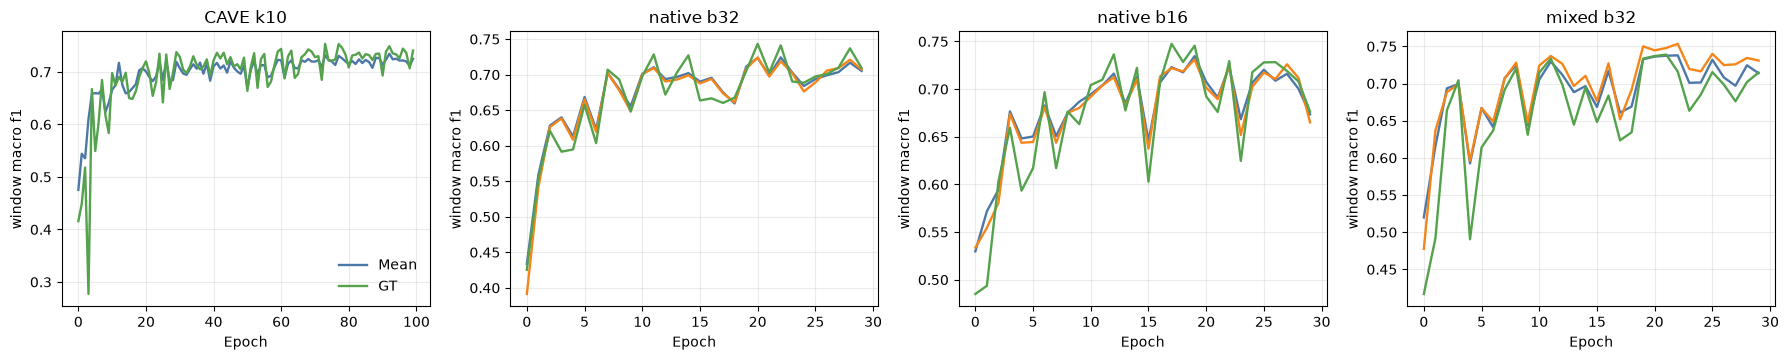

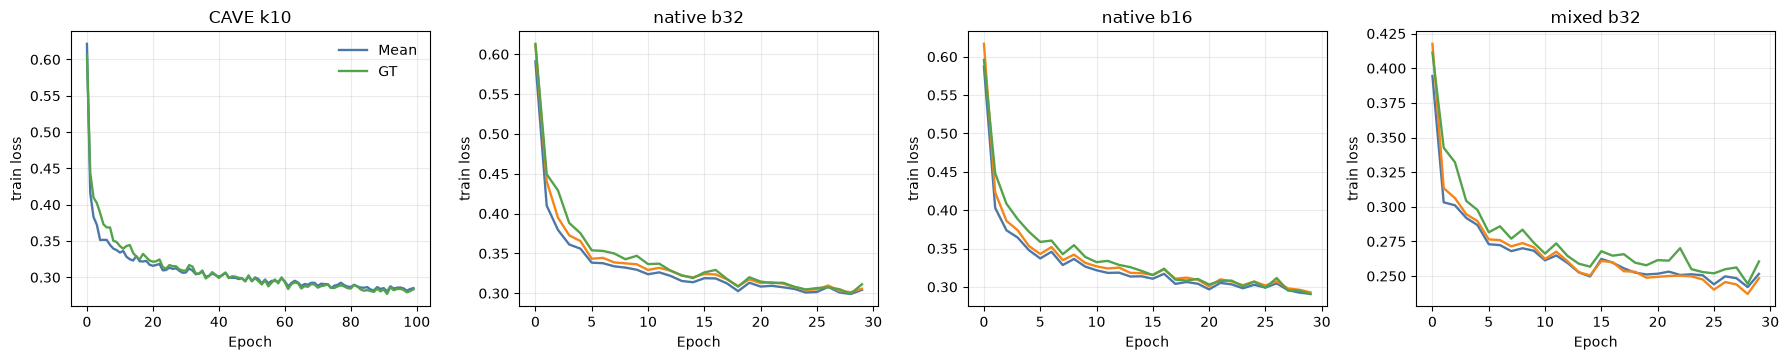

In [4]:
def plot_condition(condition, metric):
    ax = plt.gca()
    for model in MODEL_ORDER:
        if model not in CURVES[condition]: continue
        frame = CURVES[condition][model]
        ax.plot(frame.epoch, frame[metric], label=model, color=COLORS[model], lw=1.7)
    ax.set(title=condition, xlabel="Epoch", ylabel=metric.replace("_", " "))
    ax.grid(alpha=.25)

for metric in ("window_macro_f1", "train_loss"):
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.7), sharey=False)
    for ax, condition in zip(axes, RUN_DIRS, strict=True):
        plt.sca(ax); plot_condition(condition, metric)
    axes[0].legend(frameon=False)
    fig.tight_layout()
    display(fig); plt.close(fig)

In [5]:
def pair_stats(left, right, start=3):
    n = min(len(left), len(right))
    a = left.iloc[:n].reset_index(drop=True)
    b = right.iloc[:n].reset_index(drop=True)
    return {"epochs": n, "level correlation": a.corr(b),
            "change correlation": a.diff().iloc[start:].corr(b.diff().iloc[start:]),
            "mean absolute difference": (a - b).abs().mean()}

rows = []
for condition, models in CURVES.items():
    for a, b in combinations(MODEL_ORDER, 2):
        if a in models and b in models:
            rows.append({"condition": condition, "models": f"{a} / {b}",
                         **pair_stats(models[a].window_macro_f1,
                                      models[b].window_macro_f1)})
for model in MODEL_ORDER:
    rows.append({"condition": "b32 vs b16", "models": model,
                 **pair_stats(CURVES["native b32"][model].window_macro_f1,
                              CURVES["native b16"][model].window_macro_f1)})
trajectory_stats = pd.DataFrame(rows)
display(trajectory_stats.round(4))
print("CAVE Mean/GT first-30-epoch change correlation:",
      round(pair_stats(CURVES["CAVE k10"]["Mean"].window_macro_f1.iloc[:30],
                       CURVES["CAVE k10"]["GT"].window_macro_f1.iloc[:30])["change correlation"], 4))

,condition,models,epochs,level correlation,change correlation,mean absolute difference
0,CAVE k10,Mean / GT,100,0.8656,0.3977,0.0200
1,native b32,Mean / Pointwise-MLP,30,0.9978,0.9928,0.0048
2,native b32,Mean / GT,30,0.9713,0.8399,0.0132
3,native b32,Pointwise-MLP / GT,30,0.9644,0.8321,0.0137
4,native b16,Mean / Pointwise-MLP,30,0.9930,0.9884,0.0053
5,native b16,Mean / GT,30,0.9635,0.9177,0.0195
6,native b16,Pointwise-MLP / GT,30,0.9667,0.9141,0.0185
7,mixed b32,Mean / Pointwise-MLP,30,0.9826,0.9705,0.0122
8,mixed b32,Mean / GT,30,0.9629,0.9206,0.0267
9,mixed b32,Pointwise-MLP / GT,30,0.9360,0.9058,0.0340


CAVE Mean/GT first-30-epoch change correlation: 0.2481


In [6]:
raw_comparison = pd.DataFrame({
    "epoch": CURVES["native b32"]["Mean"].epoch,
    "Mean": CURVES["native b32"]["Mean"].window_macro_f1,
    "Pointwise-MLP": CURVES["native b32"]["Pointwise-MLP"].window_macro_f1,
})
raw_comparison["difference"] = raw_comparison["Pointwise-MLP"] - raw_comparison["Mean"]
display(raw_comparison)

for condition in ("native b32", "native b16", "mixed b32"):
    root = RUN_DIRS[condition]
    print(condition, {model: round(frame.window_macro_f1.max(), 4)
                      for model, frame in CURVES[condition].items()})
    mean = np.asarray(json.loads(result_json(root, "Mean").read_text())["window_test_metrics"]["confusion_matrix"])
    mlp = np.asarray(json.loads(result_json(root, "Pointwise-MLP").read_text())["window_test_metrics"]["confusion_matrix"])
    print("  Mean/MLP confusion L1:", int(np.abs(mean - mlp).sum()),
          "same class supports:", np.array_equal(mean.sum(axis=1), mlp.sum(axis=1)))

,epoch,Mean,Pointwise-MLP,difference
0,0,0.433522,0.391327,-0.042195
1,1,0.559171,0.541646,-0.017525
2,2,0.628355,0.626215,-0.002140
3,3,0.639898,0.638303,-0.001595
4,4,0.612939,0.608396,-0.004543
5,5,0.668563,0.665274,-0.003289
6,6,0.623171,0.619362,-0.003808
7,7,0.702208,0.702260,0.000051
8,8,0.679856,0.678047,-0.001809
9,9,0.655397,0.648557,-0.006839


native b32 {'GT': np.float64(0.7433), 'Mean': np.float64(0.7243), 'Pointwise-MLP': np.float64(0.7241)}
  Mean/MLP confusion L1: 22590 same class supports: True
native b16 {'GT': np.float64(0.7475), 'Pointwise-MLP': np.float64(0.731), 'Mean': np.float64(0.7347)}
  Mean/MLP confusion L1: 12292 same class supports: True
mixed b32 {'Mean': np.float64(0.7379), 'GT': np.float64(0.7389), 'Pointwise-MLP': np.float64(0.7534)}
  Mean/MLP confusion L1: 13618 same class supports: True


## Which cells and windows enter an epoch?

The source sampler groups windows from one cell into each original batch. It visits every retained window once. The experimental sampler redistributes neighboring batches to mix cells while keeping the same windows and optimizer-step count.

In [7]:
from data.dataset_lcpn import load_manifest
from data.dataset_presynaptic import PresynapticWindowDataset, AttentionBudgetBatchSampler
from data.mixed_cell_batch_sampler import MixedCellBatchSampler

native_manifest = json.loads((NATIVE_DB / "manifest.json").read_text())
train_sets = {
    "CAVE k10": PresynapticWindowDataset(load_manifest(), "train", "cave", database=CAVE_DB, cell_cache_size=1),
    "native b32": PresynapticWindowDataset(native_manifest, "train", "new", database=NATIVE_DB, cell_cache_size=1),
}
sampler_args = dict(attention_budget=14_450_688, max_windows=4096, shuffle=True, seed=0)
audit = []
for condition, ds in train_sets.items():
    sampler = AttentionBudgetBatchSampler(ds, **sampler_args)
    batches = list(sampler)
    per_cell = Counter(int(ds.index_root_ids[batch[0]]) for batch in batches)
    audit.append({"condition": condition, "cells": len(ds.cell_types), "windows": len(ds),
                  "optimizer batches": len(batches), "cells with >1 batch": sum(n > 1 for n in per_cell.values()),
                  "max batches/cell": max(per_cell.values()),
                  "all windows once": len(np.unique(np.fromiter((i for batch in batches for i in batch),
                                                        dtype=np.int64))) == len(ds)})
assert set(train_sets["CAVE k10"].cell_types) == set(train_sets["native b32"].cell_types)
mixed = MixedCellBatchSampler(train_sets["native b32"], cells_per_batch=16, **sampler_args)
mixed_batches = list(mixed)
mixed_ids = np.fromiter((i for batch in mixed_batches for i in batch), dtype=np.int64, count=len(train_sets["native b32"]))
assert np.array_equal(np.sort(mixed_ids), np.arange(len(train_sets["native b32"])))
assert len(mixed_batches) == audit[1]["optimizer batches"]
mixed_cell_counts = [len(set(train_sets["native b32"].index_root_ids[batch])) for batch in mixed_batches]
display(pd.DataFrame(audit))
print("Same training cell IDs:", True)
print("Mixed batches:", len(mixed_batches), "; median cells/batch:", np.median(mixed_cell_counts),
      "; min/max:", min(mixed_cell_counts), max(mixed_cell_counts))

,condition,cells,windows,optimizer batches,cells with >1 batch,max batches/cell,all windows once
0,CAVE k10,1767,1326381,1814,47,2,True
1,native b32,1767,1832622,1907,114,4,True


Same training cell IDs: True
Mixed batches: 1907 ; median cells/batch: 15.0 ; min/max: 3 16


## Embedding similarity

Use the same 80 cells in CAVE and native b32. For each cell, sample up to 1,000 raw node embeddings and 50 exact-unique windows. The first 25 windows estimate variation among nodes *within a window*; all 50 estimate variation among window means *within a cell*. The sample is fixed by seed 17. Squared distances are Euclidean distances in the original 64-dimensional embedding coordinates; larger values mean less uniformity.

In [8]:
def load_cell_features(path, variant):
    with np.load(path) as z:
        if variant == "cave":
            x = z["cave_observed_x"].astype(np.float32)
            lookup = {int(node): i for i, node in enumerate(z["cave_observed_node_ids"])}
        else:
            with np.load(str(z["geometry_path"])) as geo, np.load(str(z["embedding_path"])) as emb:
                original = geo["original_node_ids"]
                ids = emb["node_ids"]
                positions = np.searchsorted(ids, original)
                assert np.array_equal(ids[positions], original)
                x = emb["embeddings"][positions].astype(np.float32)
            lookup = {i: i for i in range(len(original))}
        valid = np.flatnonzero(z[f"{variant}_valid_k_window"])
        offsets = z[f"{variant}_window_offsets"]
        members = z[f"{variant}_window_members"]
        seen, rows = set(), []
        for row in valid:
            a, b = offsets[row:row+2]
            key = np.sort(members[a:b]).tobytes()
            if key not in seen:
                seen.add(key); rows.append(int(row))
        return x, lookup, offsets, members, rows

def cosine_pairs(x, count=300, seed=0):
    rng = np.random.default_rng(seed)
    a = rng.choice(len(x), size=count, replace=True)
    b = (a + rng.integers(1, len(x), size=count)) % len(x)
    y = x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), 1e-12)
    return np.mean(np.sum(y[a] * y[b], axis=1))

common_ids = sorted({p.stem for p in (CAVE_DB / "cells").glob("*.npz")}
                    & {p.stem for p in (NATIVE_DB / "cells").glob("*.npz")})
sample_ids = random.Random(17).sample(common_ids, 80)
embedding_rows = []
for condition, root, variant in (("CAVE k10", CAVE_DB, "cave"),
                                 ("native b32", NATIVE_DB, "new")):
    cell_node_var, cell_node_cos, window_node_var, window_node_cos = [], [], [], []
    cell_window_var, cell_window_cos, cell_node_centroids, cell_window_centroids = [], [], [], []
    for rid in sample_ids:
        x, lookup, offsets, members, rows = load_cell_features(root / "cells" / f"{rid}.npz", variant)
        if len(x) < 2: continue
        rng = np.random.default_rng(int(rid) % 2**32)
        nodes = x[rng.choice(len(x), size=min(len(x), 1000), replace=False)]
        center = nodes.mean(axis=0)
        cell_node_centroids.append(center)
        cell_node_var.append(np.mean(np.sum((nodes - center)**2, axis=1)))
        cell_node_cos.append(cosine_pairs(nodes, seed=int(rid) % 2**32))
        if len(rows) > 50: rows = random.Random(int(rid)).sample(rows, 50)
        means = []
        for j, row in enumerate(rows):
            a, b = offsets[row:row+2]
            indices = [lookup.get(int(node)) for node in members[a:b]]
            indices = [i for i in indices if i is not None]
            if not indices: continue
            xx = x[indices]
            mu = xx.mean(axis=0)
            means.append(mu)
            if j < 25 and len(xx) > 1:
                window_node_var.append(np.mean(np.sum((xx - mu)**2, axis=1)))
                unit = xx / np.maximum(np.linalg.norm(xx, axis=1, keepdims=True), 1e-12)
                upper = np.triu_indices(len(unit), 1)
                window_node_cos.append((unit @ unit.T)[upper].mean())
        if len(means) > 1:
            means = np.asarray(means)
            mu = means.mean(axis=0)
            cell_window_centroids.append(mu)
            cell_window_var.append(np.mean(np.sum((means - mu)**2, axis=1)))
            cell_window_cos.append(cosine_pairs(means, seed=int(rid) % 2**32))
    embedding_rows.append({
        "source": condition, "cells": len(cell_node_var),
        "node within-cell squared distance": np.mean(cell_node_var),
        "node within-cell cosine": np.mean(cell_node_cos),
        "node within-window squared distance": np.mean(window_node_var),
        "node within-window cosine": np.mean(window_node_cos),
        "window-mean within-cell squared distance": np.mean(cell_window_var),
        "window-mean within-cell cosine": np.mean(cell_window_cos),
        "between-cell node-centroid variance": np.var(cell_node_centroids, axis=0).sum(),
        "between-cell window-centroid variance": np.var(cell_window_centroids, axis=0).sum(),
    })
embedding_table = pd.DataFrame(embedding_rows)
display(embedding_table.round(4))

,source,cells,node within-cell squared distance,node within-cell cosine,node within-window squared distance,node within-window cosine,window-mean within-cell squared distance,window-mean within-cell cosine,between-cell node-centroid variance,between-cell window-centroid variance
0,CAVE k10,80,30.400200,0.4903,9.5013,0.8354,13.5769,0.7501,6.2505,4.7565
1,native b32,80,30.427601,0.4974,9.8881,0.8260,13.3865,0.7513,6.0461,4.8745


### Window-level variation across native scales

Compare exact-unique windows from the same sampled cells across b32, b16, b8, and b4. Each scale changes the number of nodes in a window while using the same underlying cell cohort.

In [9]:
scale_rows = []
for scale, k in ((32, 9), (16, 17), (8, 33), (4, 65)):
    database = NATIVE_DB.parent.parent / f"scale{scale}" / f"k{k}"
    dispersions, cosines = [], []
    for rid in sample_ids:
        x, lookup, offsets, members, rows = load_cell_features(database / "cells" / f"{rid}.npz", "new")
        if len(rows) > 25:
            rows = random.Random(int(rid)).sample(rows, 25)
        for row in rows:
            a, b = offsets[row:row+2]
            indices = [lookup.get(int(node)) for node in members[a:b]]
            indices = [i for i in indices if i is not None]
            if len(indices) < 2: continue
            xx = x[indices]
            mu = xx.mean(axis=0)
            dispersions.append(np.mean(np.sum((xx - mu)**2, axis=1)))
            unit = xx / np.maximum(np.linalg.norm(xx, axis=1, keepdims=True), 1e-12)
            upper = np.triu_indices(len(unit), 1)
            cosines.append((unit @ unit.T)[upper].mean())
    scale_rows.append({"scale": f"b{scale}", "nodes/window": k, "sampled windows": len(dispersions),
                       "within-window squared distance": np.mean(dispersions),
                       "node-pair cosine": np.mean(cosines)})
display(pd.DataFrame(scale_rows).round(4))

,scale,nodes/window,sampled windows,within-window squared distance,node-pair cosine
0,b32,9,2000,9.8831,0.8261
1,b16,17,2000,9.7769,0.8367
2,b8,33,2000,9.6524,0.8445
3,b4,65,2000,9.6594,0.8453


## Saved-model predictions on identical windows

Sample 32 windows from each of eight common held-out cells (seed 7). This checks whether close aggregate curves correspond to literally identical classifiers. The small sample is a diagnostic, not a population agreement estimate.

In [10]:
from torch_geometric.loader import DataLoader
from gnn.model import WindowClassifier

torch.set_num_threads(4)
common_test_ids = sorted(set(PresynapticWindowDataset(load_manifest(), "test", "cave", database=CAVE_DB).cell_types)
                         & set(PresynapticWindowDataset(native_manifest, "test", "new", database=NATIVE_DB).cell_types))
selected_ids = np.random.default_rng(7).choice(common_test_ids, size=8, replace=False)
agreement_rows = []
for condition, database, manifest, variant, models in (
    ("CAVE k10", CAVE_DB, load_manifest(), "cave", ("Mean", "GT")),
    ("native b32", NATIVE_DB, native_manifest, "new", MODEL_ORDER),
):
    ds = PresynapticWindowDataset(manifest, "test", variant, database=database, cell_cache_size=2)
    rng = np.random.default_rng(7)
    selected_indices = []
    for rid in selected_ids:
        choices = np.flatnonzero(ds.index_root_ids == int(rid))
        selected_indices.extend(rng.choice(choices, size=min(32, len(choices)), replace=False).tolist())
    loader = DataLoader([ds[int(i)] for i in selected_indices], batch_size=32, shuffle=False)
    trained = {}
    for model in models:
        ck = torch.load(best_checkpoint(RUN_DIRS[condition], model), map_location="cpu", weights_only=False)
        net = WindowClassifier(ck["config"], hierarchy=ds.hierarchy)
        net.load_state_dict(ck["model_state"])
        trained[model] = net.eval()
    predictions = {model: [] for model in models}
    with torch.inference_mode():
        for data in loader:
            for model, net in trained.items():
                g = net(data.x, data.edge_index, data.batch,
                        pos_enc=data.pos_enc, rel_pos=data.rel_pos,
                        has_segclr=data.has_segclr)
                predictions[model].extend(net.cls_head.predict_top_down(g)[:, -1].tolist())
    for a, b in combinations(models, 2):
        agreement_rows.append({"condition": condition, "models": f"{a} / {b}",
                               "windows": len(selected_indices),
                               "prediction agreement": np.mean(np.asarray(predictions[a]) == np.asarray(predictions[b]))})
display(pd.DataFrame(agreement_rows).round(4))

,condition,models,windows,prediction agreement
0,CAVE k10,Mean / GT,256,0.9570
1,native b32,Mean / Pointwise-MLP,256,0.9648
2,native b32,Mean / GT,256,0.9453
3,native b32,Pointwise-MLP / GT,256,0.9531


## Reading the evidence

- The CSV files and trained weights are distinct, and the two GT checkpoints have the same model configuration and parameter count.
- The native trajectories are strongly aligned *within* a scale, including their epoch-to-epoch changes. The same model's changes across b32 and b16 are not aligned in the same way.
- Every training cell and every exact-unique window appears each epoch. Native b32 has more windows and slightly more optimizer batches than CAVE.
- The mixed-cell run still shows strongly aligned trajectories. Homogeneous single-cell updates alone therefore do not explain the pattern.
- Native b32 node embeddings and window means are not unusually uniform relative to CAVE on the sampled cells.

These checks rule out several simple explanations. They do not identify the cause of the native trajectory alignment. A controlled rerun with independent sampler and initialization seeds, plus saved per-window predictions at multiple epochs, would distinguish shared batch-order effects from shared prediction changes.